In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import datetime
from pathlib import Path

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [71]:
def filter_to_shared_range(df,df_bounds,val_cols):
    parts = []
    df_bounds = df_bounds.reset_index()
    for _,row in df_bounds.iterrows():
        activity = row['activity_code']
        t_min = row['min_timestamp']
        t_max = row['max_timestamp']

        mask = (df['activity_code'] == activity) & (df['timestamp'] >= t_min) & (df['timestamp'] <= t_max)

        parts.append(df.loc[mask,['user_id','activity_code','timestamp']+val_cols])
    return pd.concat(parts,ignore_index=True)

    


In [ ]:


def filter_and_merge_sensors(accel_path, gyro_path):
    acc_column_names = ['user_id','activity_code','timestamp','ax','ay','az']
    gy_column_names = ['user_id','activity_code','timestamp','gx','gy','gz']
    acc_df = pd.read_csv(accel_path,header=None, names=acc_column_names)
    gy_df =  pd.read_csv(gyro_path,header=None, names=gy_column_names)

    acc_bounds = acc_df.groupby('activity_code')['timestamp'].agg(['min','max'])
    gy_bounds = gy_df.groupby('activity_code')['timestamp'].agg(['min','max'])

    bounds = acc_bounds.join(gy_bounds,lsuffix='_acc',rsuffix='_gy')

    df_bounds = pd.DataFrame(index=bounds.index)
    df_bounds['min_timestamp'] = bounds[['min_acc','min_gy']].max(axis=1)
    df_bounds['max_timestamp'] = bounds[['max_acc','max_gy']].min(axis=1)


    acc_filtered = filter_to_shared_range(acc_df,df_bounds,['ax','ay','az'])
    gy_filtered = filter_to_shared_range(gy_df,df_bounds,['gx','gy','gz'])


    merged_df = pd.merge(
        acc_filtered,
        gy_filtered.drop(columns='user_id'),
        on=[ 'activity_code', 'timestamp'],
    )

    merged_df = merged_df.sort_values(['activity_code','timestamp']).reset_index(drop=True)

    return merged_df

In [ ]:
accel_path = Path('phone/accel')
acc_file_names = os.listdir(accel_path)
df = pd.concat((filter_and_merge_sensors(f'phone/accel/{filename}',f'phone/gyro/{filename.replace("accel","gyro")}')  for filename in acc_file_names ))
df = df.sort_values(['user_id','activity_code'],ascending=[True,True])

In [76]:
df = df.astype(str).apply(lambda s: s.str.replace(';','',regex=False).str.strip())

numeric_cols = [
    'user_id',
    'timestamp',
    'ax', 'ay', 'az',
    'gx', 'gy', 'gz'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

In [85]:
df.head()

,user_id,activity_code,timestamp,ax,ay,az,gx,gy,gz
0,1600,A,252207918580802,-4.332779,13.361191,-0.718872,-0.853210,0.297226,0.890182
1,1600,A,252207968934806,-0.319443,13.318359,-0.232025,-0.875137,0.015472,0.162231
2,1600,A,252208019288809,1.566452,9.515274,-0.017776,-0.720169,0.388489,-0.284012
3,1600,A,252208069642813,-0.323746,5.262665,0.322342,-0.571640,1.227402,-0.241669
4,1600,A,252208119996817,-1.811676,3.710510,1.373932,-0.380493,1.202835,-0.213135


In [78]:
df.shape

(2909149, 9)

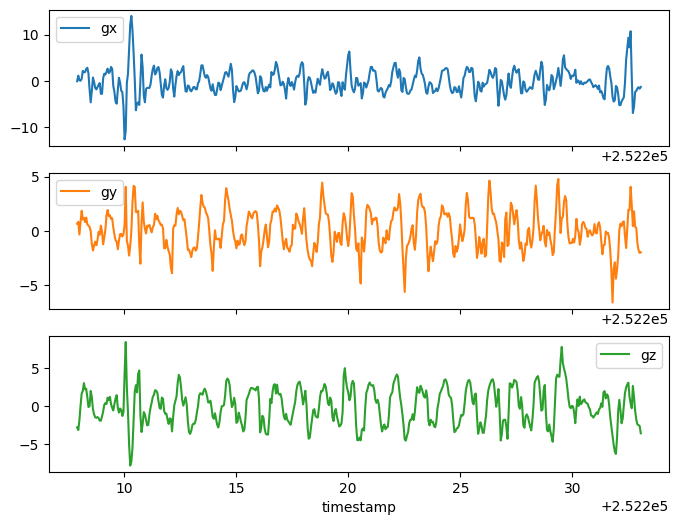

In [89]:
plot_cols = ['gx','gy','gz']
df_A = df[df['activity_code'] == 'A']
df_A = df_A [df_A['user_id'] == 1638]

plot_features = df_A[plot_cols][:500]
plot_features.index = df['timestamp'][:500]/1e9
_ = plot_features.plot(subplots=True)